In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import matplotlib.pyplot as plt
import random
import math
from PIL import Image, ImageDraw, ImageOps
import cv2

In [3]:
bubble_frame_path = os.path.join(project_root, 'Frame', 'images', 'bubble_frame')

In [2]:
def decompose_speech_bubble(contour):
    """
    Decompose a speech bubble contour into:
    - ellipse (main bubble)
    - tail polygon
    """

    contour = contour.squeeze()

    # --- compute angles at each vertex ---
    def angle(p1, p2, p3):
        v1 = p1 - p2
        v2 = p3 - p2
        v1 = v1 / np.linalg.norm(v1)
        v2 = v2 / np.linalg.norm(v2)
        return np.arccos(np.clip(np.dot(v1, v2), -1, 1))

    angles = []
    n = len(contour)

    for i in range(n):
        p1 = contour[(i-1) % n]
        p2 = contour[i]
        p3 = contour[(i+1) % n]
        angles.append(angle(p1, p2, p3))

    angles = np.array(angles)

    # tail vertices have small angle (sharp corner)
    tail_idx = np.where(angles < np.deg2rad(120))[0]

    # group contiguous indices
    tail_points = contour[tail_idx]

    # remove them from ellipse fit
    mask = np.ones(n, dtype=bool)
    mask[tail_idx] = False
    ellipse_points = contour[mask]

    ellipse_points = ellipse_points.astype(np.int32)

    # fit ellipse
    ellipse = cv2.fitEllipse(ellipse_points)

    return ellipse, tail_points

In [4]:
sample_path = os.path.join(bubble_frame_path, 'elip.png')

In [10]:
img = cv2.imread(sample_path, 0)
_,th = cv2.threshold(img,200,255,cv2.THRESH_BINARY_INV)

contours,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

ellipse, tail = decompose_speech_bubble(contours[0])

print("Ellipse:", ellipse)
print("Tail vertices:", tail)

Ellipse: ((149.17848205566406, 187.98643493652344), (224.2962646484375, 344.56463623046875), 175.7748565673828)
Tail vertices: [[254 341]
 [254 339]
 [246 332]
 [241 327]
 [198  34]]


In [11]:
cv2.ellipse(img, ellipse, (0,255,0), 2)

# draw tail polygon
tail_pts = np.array(tail, dtype=np.int32)
cv2.polylines(img, [tail_pts], True, (0,0,255), 2)

# mark tail vertices
for p in tail_pts:
    cv2.circle(img, tuple(p), 4, (255,0,0), -1)

cv2.imshow("decomposition", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

(np.float64(-0.5), np.float64(310.5), np.float64(384.5), np.float64(-0.5))

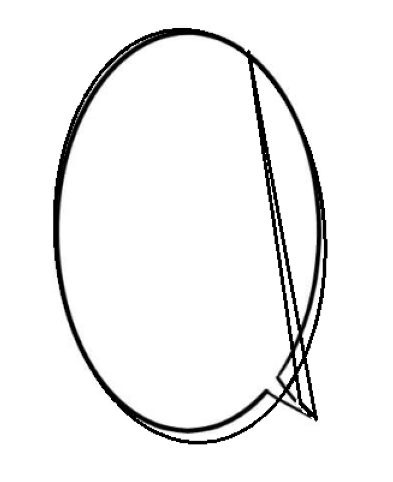

In [12]:
vis = img.copy()
cv2.ellipse(vis, ellipse, (0,255,0), 2)
cv2.polylines(vis, [tail_pts], True, (0,0,255), 2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")